<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_005_clustering/05a_Gaussian_Mixtures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de Mezclas Gaussianas
Eduardo Zurek, Ph.D.
Inteligencia Artificial
Ingeniería de Sistemas
Universidad del Norte
Abril 20 de 2021, 7:08 p.m.

## Librerías requeridas

In [91]:
try:
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import multivariate_normal
except ImportError:
  !pip install numpy
  !pip install matplotlib
  !pip install scipy
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import multivariate_normal

## Generación de datos sintéticos

La primera figura muestra los grupos ideales generados aleatoriamente y etiquetados

La segunda figura muestra un solo grupo, estos son los datos que se usarán para aplicar el algoritmo

(1000, 2)
(1000,)
(1000,)


/tmp/ipykernel_2611/3512894423.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x1, y1 = np.random.multivariate_normal(m1, c1, 500).T
/tmp/ipykernel_2611/3512894423.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x2, y2 = np.random.multivariate_normal(m2, c2, 500).T


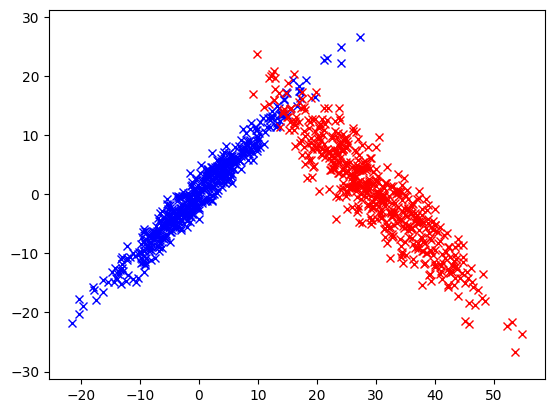

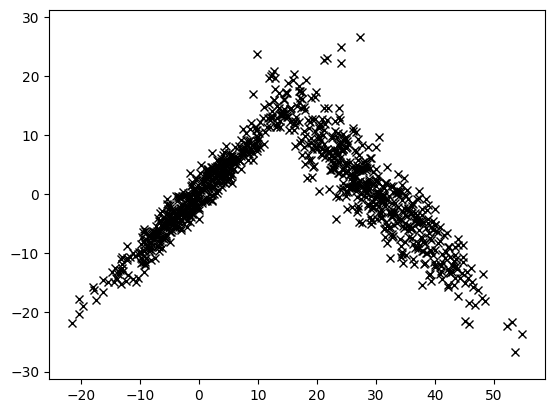

In [92]:
#import numpy as np
#import matplotlib.pyplot as plt
m1 = [0,0]
c1 = [[100,100],[-3,-5]]
x1, y1 = np.random.multivariate_normal(m1, c1, 500).T
m2 = [30,0]
c2 = [[-100,100],[-3,-5]]
x2, y2 = np.random.multivariate_normal(m2, c2, 500).T
x = np.concatenate((np.array(x1),np.array(x2)),axis=0)
y = np.concatenate((np.array(y1),np.array(y2)),axis=0)
datos = np.column_stack((x,y))
print(datos.shape)
print(x.shape)
print(y.shape)
plt.plot(x1, y1, 'xb')
plt.plot(x2, y2, 'xr')
plt.axis('equal')
plt.show()
plt.plot(x, y, 'xk')
plt.axis('equal')
plt.show()

## Valores iniciales
En la primera iteración se inicializan los centroides y las matrices de covarianza con números aleatorios

Se debe garantizar que las matrices de covarianza sean simétricas positivas

La variable delta se usará para guardar el mayor cambio en los valores de los centroides y las covarianzas

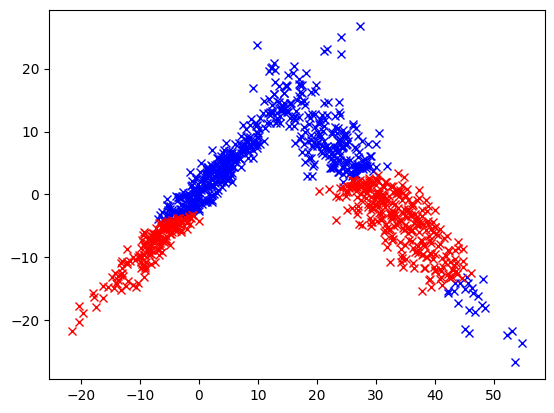

Centroide 1 = 
[33.32148137 -6.65992518]
Covarianza 1
[[3920.2501976  3029.38104585]
 [3029.38104585 2574.58708812]]
Centroide 2 = 
[ 12.8895551  -14.84947594]
Covarianza 2
[[2638.15283623 1078.42551704]
 [1078.42551704  490.6308565 ]]


In [93]:
ma_x = np.max(x)
mi_x = np.min(x)
ma_y = np.max(y)
mi_y = np.min(y)
mi_t = np.min([mi_x,mi_y])
ma_t = np.max([ma_x,ma_y])
xc = np.random.rand(1,2)*(ma_x-mi_x)+mi_x
yc = np.random.rand(1,2)*(ma_y-mi_y)+mi_y
c1 = np.array([xc[0][0],yc[0][0]])
c2 = np.array([xc[0][1],yc[0][1]])
cov1 = np.random.rand(2,2)*(ma_t-mi_t)+mi_t
cov1 = cov1.dot(cov1.T)
cov2 = np.random.rand(2,2)*(ma_t-mi_t)+mi_t
cov2 = cov2.dot(cov2.T)
delta = 100
p1 = multivariate_normal.pdf(datos,c1, cov1)
p2 = multivariate_normal.pdf(datos,c2, cov2)
i1 = p1 > p2
i2 = ~i1
d1 = datos[i1,:]
d2 = datos[i2,:]
plt.plot(d1[:,0],d1[:,1], 'xb')
plt.plot(d2[:,0],d2[:,1], 'xr')
plt.show()
print("Centroide 1 = ")
print(c1)
print("Covarianza 1")
print(cov1)
print("Centroide 2 = ")
print(c2)
print("Covarianza 2")
print(cov2)

## Iteraciones siguientes
Con los datos separados en la iteración anterior, se recalculan los centroides y las matrices de covarianza

El proceso se repite hasta que no se perciban cambios significativos en los parámetros

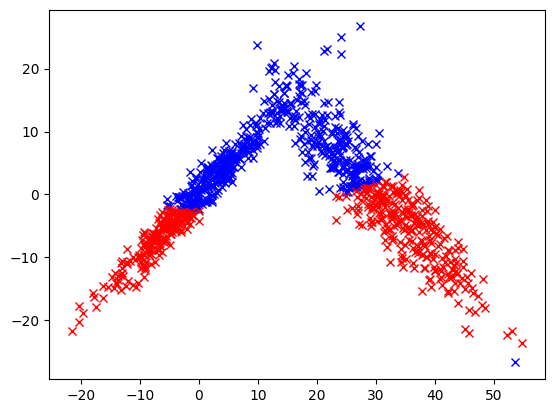

Centroide 1 = 
[11.74650257  4.87246564]
Covarianza 1
[[154.92141267   0.52819541]
 [  0.52819541  55.42432051]]
Centroide 2 = 
[18.69173218 -5.58860869]
Covarianza 2
[[432.51429853  35.45241532]
 [ 35.45241532  23.21904175]]
Delta = 
3765.3287849247877


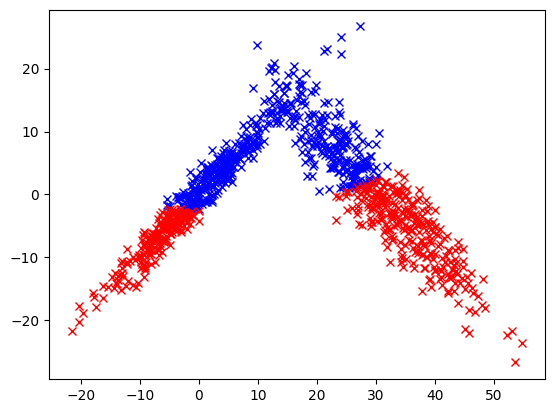

Centroide 1 = 
[12.28135613  6.06466762]
Covarianza 1
[[110.92367043  20.97033647]
 [ 20.97033647  32.38756149]]
Centroide 2 = 
[17.77764348 -6.51034325]
Covarianza 2
[[480.66254911   8.80554652]
 [  8.80554652  24.58585548]]
Delta = 
48.14825058032386


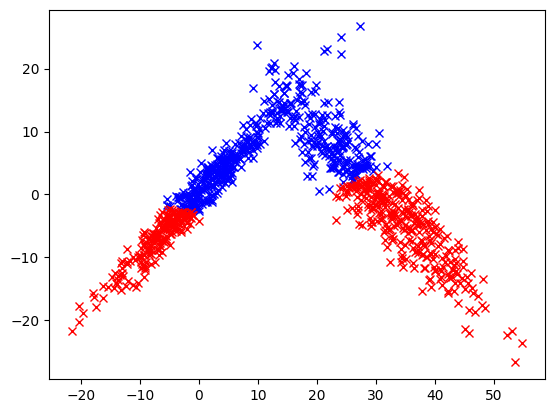

Centroide 1 = 
[11.98266086  6.23603891]
Covarianza 1
[[104.56960656  24.8100552 ]
 [ 24.8100552   30.41938804]]
Centroide 2 = 
[17.96687236 -6.38188844]
Covarianza 2
[[475.32954341   8.35278504]
 [  8.35278504  26.14304421]]
Delta = 
6.354063862466219


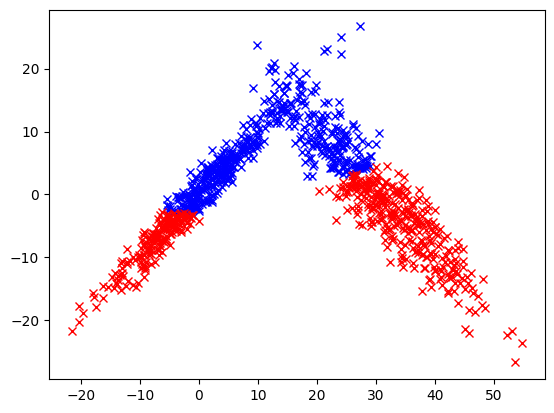

Centroide 1 = 
[11.26765795  6.36943359]
Covarianza 1
[[99.230542   29.28586551]
 [29.28586551 31.09697516]]
Centroide 2 = 
[18.47871208 -6.05914424]
Covarianza 2
[[459.03893036  11.6054696 ]
 [ 11.6054696   27.84495676]]
Delta = 
16.29061304825376


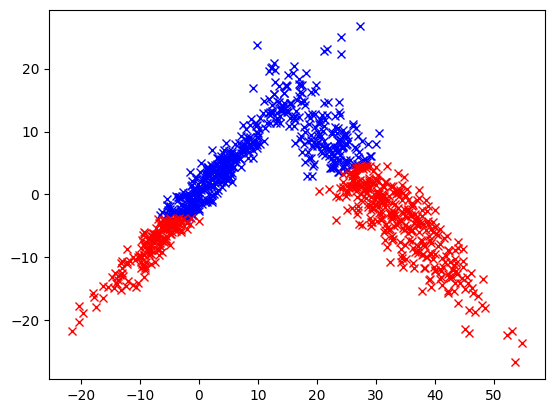

Centroide 1 = 
[10.53538795  6.24835676]
Covarianza 1
[[97.90043733 33.74510341]
 [33.74510341 32.72977197]]
Centroide 2 = 
[19.20825447 -5.91105694]
Covarianza 2
[[447.93652595  15.10787987]
 [ 15.10787987  29.53184656]]
Delta = 
11.102404410696806


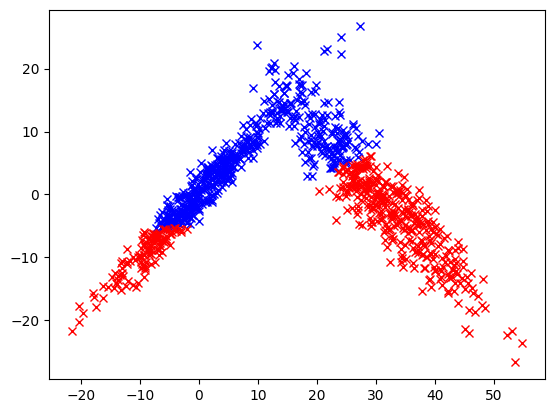

Centroide 1 = 
[9.41261185 5.90382063]
Covarianza 1
[[95.31864707 39.81002379]
 [39.81002379 36.01167377]]
Centroide 2 = 
[20.48305653 -5.70134889]
Covarianza 2
[[430.74095697  20.31100036]
 [ 20.31100036  32.83301673]]
Delta = 
17.195568978879294


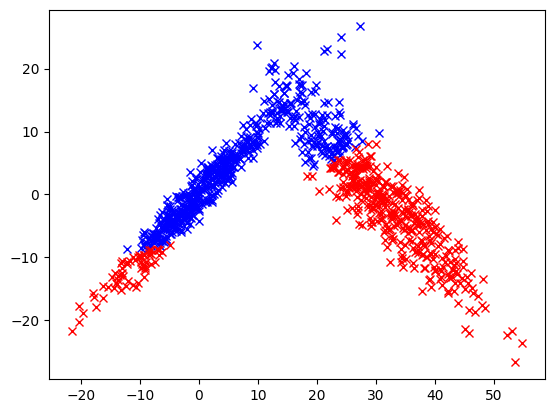

Centroide 1 = 
[7.93847257 5.15917089]
Covarianza 1
[[95.52120148 48.02674326]
 [48.02674326 41.7321028 ]]
Centroide 2 = 
[22.8062682  -5.49143972]
Covarianza 2
[[396.75108691  25.43817857]
 [ 25.43817857  37.80403873]]
Delta = 
33.98987006317742


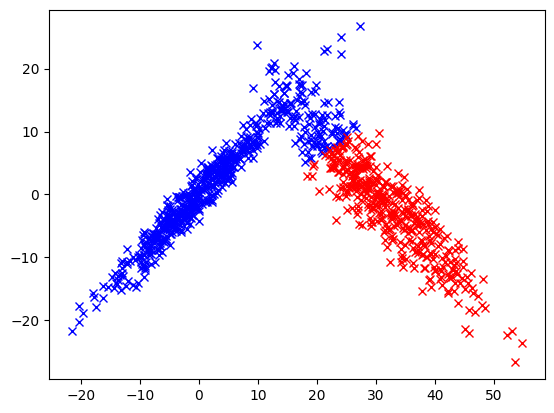

Centroide 1 = 
[5.89869304 3.94174466]
Covarianza 1
[[98.56276797 60.31792012]
 [60.31792012 52.07756401]]
Centroide 2 = 
[26.93030881 -4.82168379]
Covarianza 2
[[295.0632212   20.06526478]
 [ 20.06526478  45.71192154]]
Delta = 
101.68786570459491


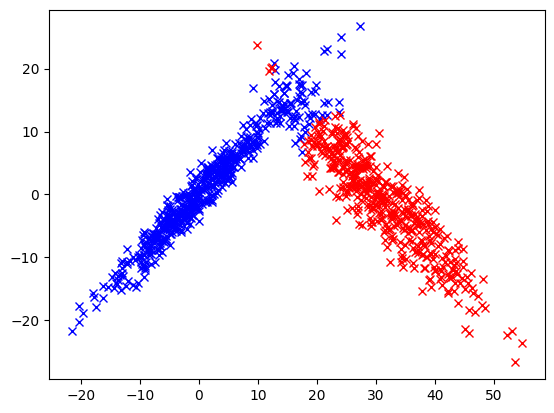

Centroide 1 = 
[3.31279256 2.14702774]
Covarianza 1
[[104.62241854  79.70049327]
 [ 79.70049327  73.16261109]]
Centroide 2 = 
[32.86237508 -2.80102398]
Covarianza 2
[[ 47.12568712 -40.26716833]
 [-40.26716833  45.40159863]]
Delta = 
247.9375340799531


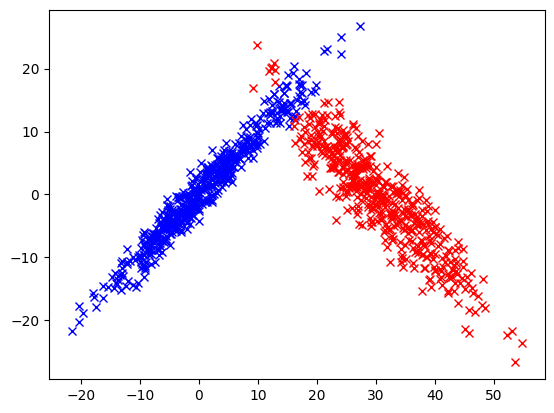

Centroide 1 = 
[1.53173996 1.36773445]
Covarianza 1
[[79.4314353  73.2728254 ]
 [73.2728254  72.70139281]]
Centroide 2 = 
[31.36445248 -1.21174287]
Covarianza 2
[[ 58.30987744 -52.62119917]
 [-52.62119917  58.86273087]]
Delta = 
25.190983241431738


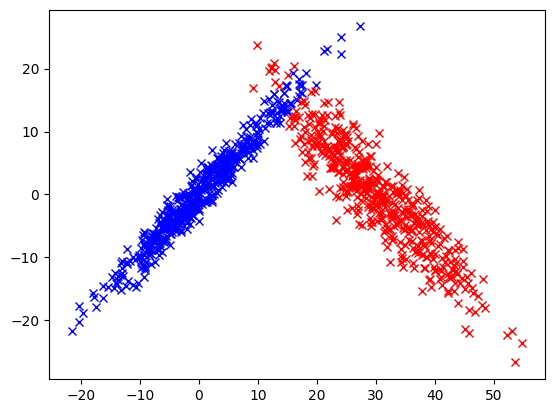

Centroide 1 = 
[0.7540005  0.82872106]
Covarianza 1
[[69.20568489 67.61528541]
 [67.61528541 69.1727149 ]]
Centroide 2 = 
[30.65448722 -0.46943923]
Covarianza 2
[[ 64.84565723 -59.44675866]
 [-59.44675866  66.16750603]]
Delta = 
10.225750408896872


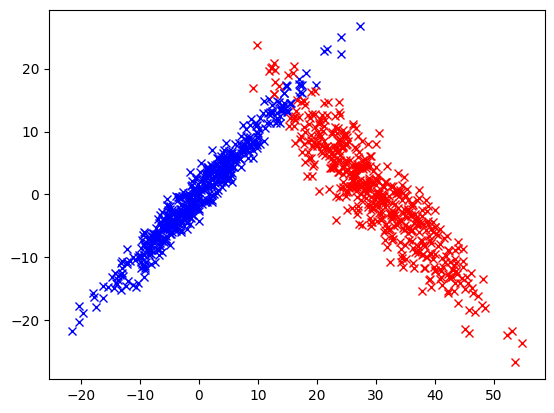

Centroide 1 = 
[0.35389829 0.47383409]
Covarianza 1
[[64.36091861 63.52817826]
 [63.52817826 65.59547472]]
Centroide 2 = 
[30.27793022 -0.05622071]
Covarianza 2
[[ 68.31757793 -63.49088246]
 [-63.49088246  70.78669149]]
Delta = 
4.844766283580029


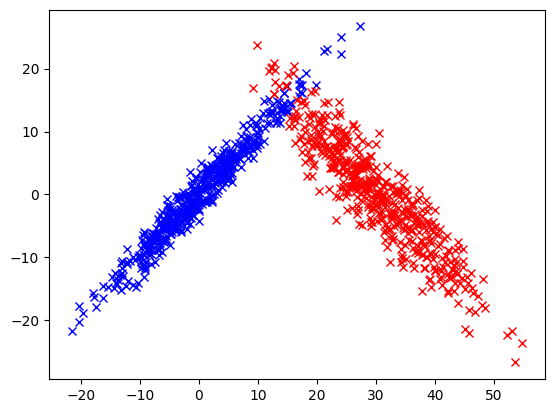

Centroide 1 = 
[0.24333055 0.34804069]
Covarianza 1
[[63.25918442 62.22312694]
 [62.22312694 64.04248243]]
Centroide 2 = 
[30.14865677  0.08010397]
Covarianza 2
[[ 69.80935543 -65.1013471 ]
 [-65.1013471   72.48082825]]
Delta = 
1.6941367658839823


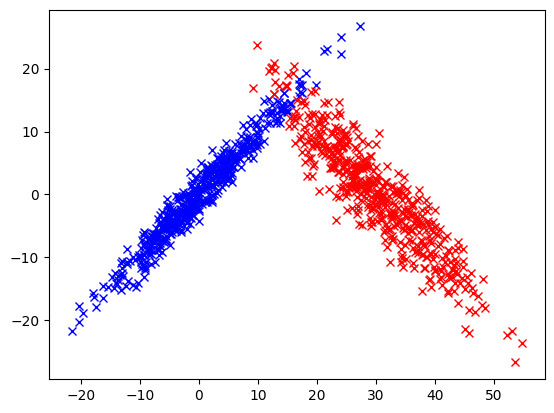

Centroide 1 = 
[0.18644388 0.28167255]
Covarianza 1
[[62.67767152 61.49918581]
 [61.49918581 63.16426657]]
Centroide 2 = 
[30.08580279  0.15027462]
Covarianza 2
[[ 70.48976831 -65.91343166]
 [-65.91343166  73.38830829]]
Delta = 
0.907480034007591


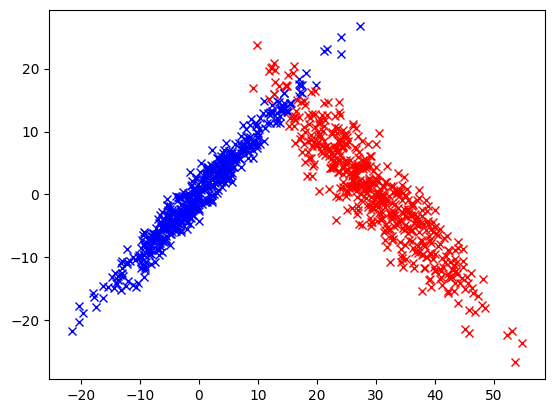

Centroide 1 = 
[0.15746955 0.24840534]
Covarianza 1
[[62.37205904 61.1276931 ]
 [61.1276931  62.72307399]]
Centroide 2 = 
[30.05494449  0.18502901]
Covarianza 2
[[ 70.81345897 -66.30549309]
 [-66.30549309  73.83159931]]
Delta = 
0.44329102619505534


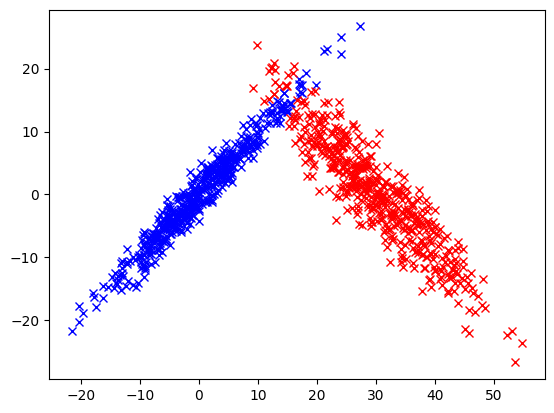

Centroide 1 = 
[0.13450644 0.21889173]
Covarianza 1
[[62.22615363 60.90261857]
 [60.90261857 62.40254762]]
Centroide 2 = 
[30.01788713  0.21563123]
Covarianza 2
[[ 71.34487374 -66.72839758]
 [-66.72839758  74.14198527]]
Delta = 
0.5314147753220055


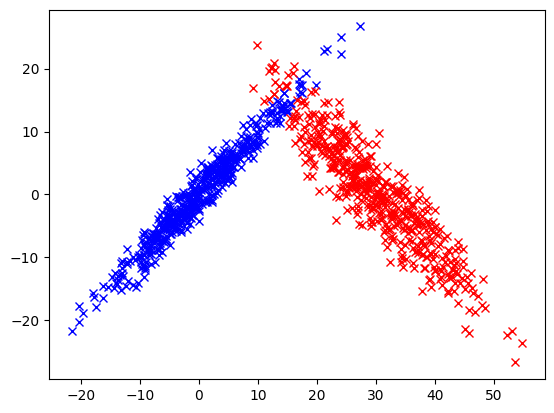

Centroide 1 = 
[0.11312753 0.1900889 ]
Covarianza 1
[[62.11648585 60.70954835]
 [60.70954835 62.10360139]]
Centroide 2 = 
[29.97925778  0.24525861]
Covarianza 2
[[ 71.93553162 -67.15700261]
 [-67.15700261  74.42403656]]
Delta = 
0.5906578794036506


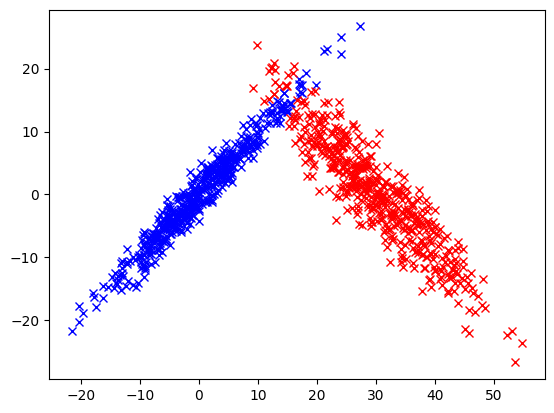

Centroide 1 = 
[0.11312753 0.1900889 ]
Covarianza 1
[[62.11648585 60.70954835]
 [60.70954835 62.10360139]]
Centroide 2 = 
[29.97925778  0.24525861]
Covarianza 2
[[ 71.93553162 -67.15700261]
 [-67.15700261  74.42403656]]
Delta = 
0.0


In [94]:
while delta > 0.01:
  c1a = c1
  c2a = c2
  cov1a = cov1
  cov2a = cov2
  cov1 = np.cov(d1.T)
  cov2 = np.cov(d2.T)
  c1 = np.array([np.mean(d1[:,0]),np.mean(d1[:,1])])
  c2 = np.array([np.mean(d2[:,0]),np.mean(d2[:,1])])
  p1 = multivariate_normal.pdf(datos,c1, cov1)
  p2 = multivariate_normal.pdf(datos,c2, cov2)
  i1 = p1 > p2
  i2 = ~i1
  d1 = datos[i1,:]
  d2 = datos[i2,:]
  plt.plot(d1[:,0],d1[:,1], 'xb')
  plt.plot(d2[:,0],d2[:,1], 'xr')
  plt.show()
  print("Centroide 1 = ")
  print(c1)
  print("Covarianza 1")
  print(cov1)
  print("Centroide 2 = ")
  print(c2)
  print("Covarianza 2")
  print(cov2)
  delta = np.max([np.max(np.abs(cov1-cov1a)),np.max(np.abs(cov2-cov2a)),np.max(np.abs(c1-c1a)),np.max(np.abs(c2-c2a))])
  print("Delta = ")
  print(delta)